---
## Git Quick Reference: Pushing This Notebook to GitHub

Use these commands in your **terminal** (not in Python) to push your work to GitHub.

### First-Time Setup (do once)
```bash
# Configure your identity
git config --global user.name "Your Name"
git config --global user.email "your@email.com"

# Create a repository folder and initialize
mkdir MSDS640-coursework
cd MSDS640-coursework
git init

# Connect to your GitHub repo (replace with YOUR URL)
git remote add origin git@github.com:YOUR_USERNAME/MSDS640-coursework.git
```

### Push Your Work (do after every session)
```bash
# Check what files have changed
git status

# Stage files for commit
git add Session1_Ridge_Lasso_Practice.ipynb

# Save a snapshot with a message describing what you did
git commit -m "Complete Week 1 Ridge/Lasso practice"

# Upload to GitHub
git push -u origin main
```

### Pull Updates (get code from GitHub)
```bash
# Download and merge latest changes
git pull origin main
```

### Essential Commands Cheat Sheet

| Command | What It Does |
|---------|-------------|
| `git init` | Initialize a new local repository |
| `git clone <url>` | Download an existing repo from GitHub |
| `git status` | See which files are modified/staged |
| `git add <file>` | Stage a file for the next commit |
| `git commit -m "msg"` | Save a snapshot with a description |
| `git push` | Upload commits to GitHub |
| `git pull` | Download and merge from GitHub |
| `git log --oneline` | View commit history (compact) |
| `git diff` | See what changed since last commit |

**Assignment:** Keep a record of every command you run and what it does!

---

## Background: The Regularization Framework

### The General Regression Problem

In **Ordinary Least Squares (OLS)**, we minimize the residual sum of squares:

$$\hat{w} = \arg\min_w \; \underbrace{\sum_{i=1}^n (y_i - w^T x_i)^2}_{\text{RSS — Residual Sum of Squares}}$$

This finds the best fit to training data, but with many features it can **overfit** — the model fits noise in the training data and performs poorly on new data.

### The Regularized Version (General Form)

Regularization adds a **penalty term** that constrains the coefficients:

$$\hat{w} = \arg\min_w \; \underbrace{\sum_{i=1}^n (y_i - w^T x_i)^2}_{\text{Data fit (RSS)}} + \underbrace{\lambda \cdot \Omega(w)}_{\text{Penalty (regularizer)}}$$

Where $\Omega(w)$ is the regularization function and $\lambda$ (called `alpha` in sklearn) controls the strength.

---

### Ridge Regression (L2 Regularization)

$$\hat{w}_{\text{Ridge}} = \arg\min_w \; \sum_{i=1}^n (y_i - w^T x_i)^2 + \alpha \sum_{j=1}^p w_j^2$$

**Penalty:** $\|w\|_2^2 = w_1^2 + w_2^2 + \ldots + w_p^2$ (squared L2 norm)

**Closed-form solution:** $\hat{w} = (X^T X + \alpha I)^{-1} X^T y$

**Effect:** Shrinks ALL coefficients toward zero, but never exactly to zero.

---

### Lasso Regression (L1 Regularization)

$$\hat{w}_{\text{Lasso}} = \arg\min_w \; \sum_{i=1}^n (y_i - w^T x_i)^2 + \alpha \sum_{j=1}^p |w_j|$$

**Penalty:** $\|w\|_1 = |w_1| + |w_2| + \ldots + |w_p|$ (L1 norm)

**No closed-form** — solved iteratively (coordinate descent).

**Effect:** Shrinks coefficients AND can set some exactly to zero → automatic feature selection.

---

### ElasticNet (L1 + L2 Combined)

$$\hat{w}_{\text{EN}} = \arg\min_w \; \sum_{i=1}^n (y_i - w^T x_i)^2 + \alpha \left[ \rho \sum_{j=1}^p |w_j| + \frac{(1-\rho)}{2} \sum_{j=1}^p w_j^2 \right]$$

**Parameters:**
- $\alpha$ = overall regularization strength (`alpha` in sklearn)
- $\rho$ = mixing ratio between L1 and L2 (`l1_ratio` in sklearn)
  - $\rho = 1$ → pure Lasso
  - $\rho = 0$ → pure Ridge
  - $0 < \rho < 1$ → blend of both

**Effect:** Performs feature selection (like Lasso) while handling correlated features stably (like Ridge).

---

### Summary Table

| Method | Penalty $\Omega(w)$ | Sparsity? | Handles Correlation? | # Hyperparams |
|--------|--------------------:|:---------:|:-------------------:|:-------------:|
| OLS | None | No | No | 0 |
| Ridge | $\sum w_j^2$ | No | Yes | 1 ($\alpha$) |
| Lasso | $\sum \|w_j\|$ | Yes | No | 1 ($\alpha$) |
| ElasticNet | $\rho\sum\|w_j\| + \frac{1-\rho}{2}\sum w_j^2$ | Yes | Yes | 2 ($\alpha$, $\rho$) |

---
## Setup: Imports

All the libraries you will need are imported below.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score

---
## Part 1: Load and Explore the Data

We will use the **California Housing** dataset (a modern replacement for Boston Housing).

**Your tasks:**
1. Load the dataset using `fetch_california_housing()`
2. Create a DataFrame with the feature names as columns
3. Print the shape, first 5 rows, and `.describe()` statistics

**Functions to use:**
- `fetch_california_housing()` — returns object with `.data`, `.target`, `.feature_names`, `.DESCR`
- `pd.DataFrame(data, columns=...)` — create a DataFrame
- `.shape`, `.head()`, `.describe()` — DataFrame inspection methods

In [2]:
fetch_california_housing()

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]]),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894]),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': '.. _california_housing_dataset:\n

In [3]:
# TODO: Load the California Housing dataset
housing = fetch_california_housing()

# TODO: Create X (features) and y (target)
X = housing.data
y = housing.target
feature_names = housing.feature_names

# TODO: Print the dataset description to understand the features
print(str(housing.DESCR))

# TODO: Create a DataFrame and display .describe()
df= pd.DataFrame(X, columns=feature_names)
df.head()
df.describe()

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000


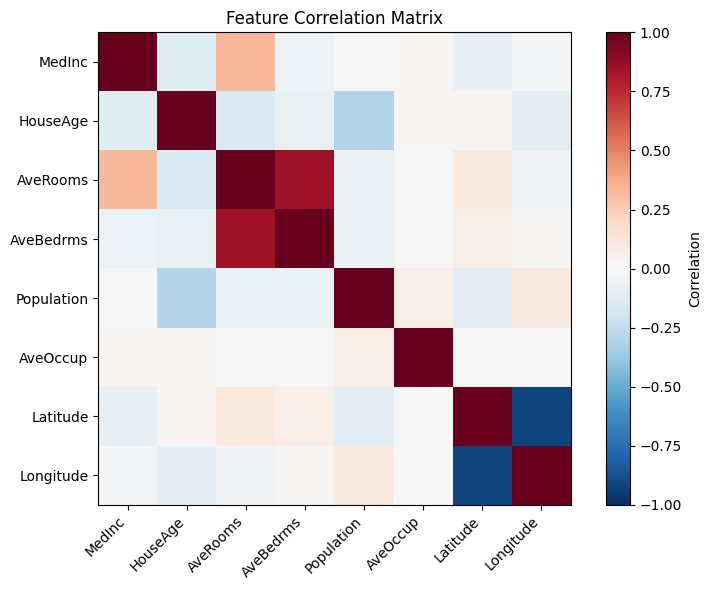

In [4]:
# TODO: Plot a correlation matrix to see which features are correlated
# This motivates WHY regularization (especially Ridge) helps — correlated features
# make OLS coefficients unstable.
#
df = pd.DataFrame(X, columns=feature_names)
corr = df.corr()
plt.figure(figsize=(8, 6))
plt.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(label='Correlation')
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha='right')
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

# Look for pairs with correlation > 0.7 or < -0.7 — these will cause problems for OLS.

---
## Part 2: Train/Test Split and Baseline Model

**Your tasks:**
1. Split the data: 80% train, 20% test (use `random_state=42`)
2. Train a plain `LinearRegression()` on the raw features
3. Compute RMSE and R² on both train and test sets

**Functions to use:**
- `train_test_split(X, y, test_size=0.2, random_state=42)` — splits data
- `LinearRegression()` — creates model; `.fit(X, y)` trains it; `.predict(X)` gets predictions
- `mean_squared_error(y_true, y_pred)` — computes MSE; wrap in `np.sqrt()` for RMSE
- `r2_score(y_true, y_pred)` — computes R² (coefficient of determination)

In [5]:
# TODO: Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# TODO: Train a basic LinearRegression model
linreg = LinearRegression()
linreg.fit(X_train, y_train)

# TODO: Compute predictions on train and test
p_train = linreg.predict(X_train)
p_test = linreg.predict(X_test)

# TODO: Compute RMSE and R² for both sets
rmse_train_baseline = np.sqrt(mean_squared_error(y_train, p_train))
rmse_test_baseline = np.sqrt(mean_squared_error(y_test, p_test))
r2_train_baseline = r2_score(y_train, p_train)
r2_test_baseline = r2_score(y_test, p_test)

# Print results
print("Baseline Linear Regression (raw features):")
print(f"  Train RMSE: {rmse_train_baseline:.4f}, R²: {r2_train_baseline:.4f}")
print(f"  Test  RMSE: {rmse_test_baseline:.4f}, R²: {r2_test_baseline:.4f}")


Baseline Linear Regression (raw features):
  Train RMSE: 0.7197, R²: 0.6126
  Test  RMSE: 0.7456, R²: 0.5758


---
## Part 3: Create an Overfitting Scenario with Polynomial Features

Now we'll engineer a situation where regularization clearly helps. By adding **polynomial features** (degree=2), we create many more parameters than needed — the model will overfit.

**Your tasks:**
1. Expand features using `PolynomialFeatures(degree=2, include_bias=False)`
2. Scale the expanded features with `StandardScaler`
3. Train `LinearRegression()` on the polynomial features
4. Compute RMSE on train and test — observe the overfitting gap!

**Functions to use:**
- `PolynomialFeatures(degree=2, include_bias=False)` — creates polynomial/interaction features
  - `.fit_transform(X_train)` — fit on train AND transform
  - `.transform(X_test)` — transform test using same expansion (never fit on test!)
- `StandardScaler()` — standardizes features to mean=0, std=1
  - `.fit_transform(X_train)` — fit on train AND transform
  - `.transform(X_test)` — apply same scaling to test
- Check `X_train_poly.shape[1]` to see how many features you created

In [6]:
# TODO: Create polynomial features (degree=2)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# TODO: Print how many features you now have
print(f"Original features: {X_train.shape[1]}")
print(f"Polynomial features: {X_train_poly.shape[1]}")

# TODO: Scale the polynomial features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_poly)
X_test_scaled = scaler.transform(X_test_poly)

# TODO: Train LinearRegression on the scaled polynomial features
linreg_poly = LinearRegression()
linreg_poly.fit(X_train_scaled, y_train)

# TODO: Compute RMSE on train and test
rmse_train_poly = np.sqrt(mean_squared_error(y_train, linreg_poly.predict(X_train_scaled)))
rmse_test_poly = np.sqrt(mean_squared_error(y_test, linreg_poly.predict(X_test_scaled)))

# Print results — you should see a BIG gap between train and test
print(f"  Train RMSE: {rmse_train_poly:.4f}")
print(f"  Test  RMSE: {rmse_test_poly:.4f}")
print(f"  Gap (overfitting): {rmse_test_poly - rmse_train_poly:.4f}")


Original features: 8
Polynomial features: 44
  Train RMSE: 0.6486
  Test  RMSE: 0.6814
  Gap (overfitting): 0.0328


**Question:** How many features does degree=2 polynomial expansion create from 8 original features? Why does this lead to overfitting?

*Your answer: it ends with 44 making a difference of 36 feature from the orginal 8. You arent adding any new information while at the same time increasing the complexity of the data the model trains on.



---
## Part 4: Ridge Regression (L2 Regularization)

### Formula Reminder

$$\text{Loss}_{\text{Ridge}} = \sum_{i=1}^n (y_i - \hat{y}_i)^2 + \alpha \sum_{j=1}^p w_j^2$$

The penalty discourages large coefficients. As $\alpha$ increases, coefficients shrink more.

**Your tasks:**
1. Study the worked example below (single alpha)
2. Extend it to loop over multiple alpha values: `[0.001, 0.01, 0.1, 1.0, 10.0, 100.0]`
3. Find the alpha that gives the best test RMSE

**Functions to use:**
- `Ridge(alpha=1.0)` — creates a Ridge model
  - `.fit(X_train, y_train)` — train the model
  - `.predict(X_test)` — get predictions
  - `.coef_` — access the learned coefficients (after fitting)
- Store results in lists for plotting: `ridge_train_rmses = []`, `ridge_test_rmses = []`

**⚠️ Important:** Why does Ridge have `max_iter` optional but Lasso requires it? Because Ridge has a **closed-form solution** $(X^TX + \alpha I)^{-1}X^Ty$ — it doesn't iterate. Lasso uses coordinate descent (iterative).

In [7]:
# ============================================================
# WORKED EXAMPLE: Training Ridge with a SINGLE alpha value
# Study this pattern — you'll extend it to multiple alphas below
# ============================================================

# Step 1: Create the model with a specific alpha
ridge_example = Ridge(alpha=1.0)

# Step 2: Fit on training data
ridge_example.fit(X_train_scaled, y_train)

# Step 3: Get predictions on both sets
pred_train = ridge_example.predict(X_train_scaled)
pred_test = ridge_example.predict(X_test_scaled)

# Step 4: Compute RMSE for both sets
rmse_train = np.sqrt(mean_squared_error(y_train, pred_train))
rmse_test = np.sqrt(mean_squared_error(y_test, pred_test))

# Step 5: Report results
print(f"Ridge (alpha=1.0):")
print(f"  Train RMSE: {rmse_train:.4f}")
print(f"  Test  RMSE: {rmse_test:.4f}")
print(f"  Gap:        {rmse_test - rmse_train:.4f}")
print(f"  Coefficients: max={np.max(np.abs(ridge_example.coef_)):.3f}, min={np.min(np.abs(ridge_example.coef_)):.6f}")

Ridge (alpha=1.0):
  Train RMSE: 0.6648
  Test  RMSE: 0.6877
  Gap:        0.0229
  Coefficients: max=5.270, min=0.046222


In [8]:
# ============================================================
# YOUR TURN: Extend to MULTIPLE alpha values
# Same pattern as above — but now loop and collect results
# ============================================================

# TODO: Define alpha values to try
alphas = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]

# TODO: Create empty lists to store results
ridge_train_rmses = []
ridge_test_rmses = []

# TODO: Loop over alphas — repeat the pattern from the worked example
# For each alpha: create Ridge, fit, predict, compute RMSE, append to lists
for alpha in alphas:
  ridge_example = Ridge(alpha=alpha)
  ridge_example.fit(X_train_scaled, y_train)
  ridge_train_rmses.append(np.sqrt(mean_squared_error(y_train, ridge_example.predict(X_train_scaled))))
  ridge_test_rmses.append(np.sqrt(mean_squared_error(y_test, ridge_example.predict(X_test_scaled))))
  pass
DFresults = pd.DataFrame({'Alpha': alphas, 'Train RMSE': ridge_train_rmses, 'Test RMSE': ridge_test_rmses})
DFresults['Gap'] = DFresults['Train RMSE'] - DFresults['Test RMSE']
print(DFresults)
# TODO: Print a table of results
# Expected output format:
#      Alpha    Train RMSE     Test RMSE       Gap
# ---------------------------------------------------
#      0.001        0.5xxx        0.5xxx    0.0xxx
#      ...
#
# Expected: Best alpha is around 1.0-10.0 for this dataset.
# At alpha=100, BOTH train and test RMSE rise (underfitting).

# TODO: Save the best Ridge model
best_idx_ridge = np.argmin(ridge_test_rmses)
best_ridge_alpha = alphas[best_idx_ridge]
best_ridge = Ridge(alpha=best_ridge_alpha)
best_ridge.fit(X_train_scaled, y_train)
print(f"\nBest Ridge: alpha={best_ridge_alpha}")
print(f"  Test RMSE: {ridge_test_rmses[best_idx_ridge]:.4f}")

     Alpha  Train RMSE  Test RMSE       Gap
0    0.001    0.648646   0.677738 -0.029092
1    0.010    0.649221   0.660992 -0.011771
2    0.100    0.653976   0.667533 -0.013558
3    1.000    0.664799   0.687665 -0.022866
4   10.000    0.676970   0.706375 -0.029405
5  100.000    0.692150   0.713338 -0.021187

Best Ridge: alpha=0.01
  Test RMSE: 0.6610


---
## Part 5: Lasso Regression (L1 Regularization)

### Formula Reminder

$$\text{Loss}_{\text{Lasso}} = \sum_{i=1}^n (y_i - \hat{y}_i)^2 + \alpha \sum_{j=1}^p |w_j|$$

The L1 penalty can drive coefficients to **exactly zero** — performing automatic feature selection.

**Your tasks:**
1. Study the worked example below (single alpha)
2. Extend it to loop over multiple alpha values: `[0.001, 0.01, 0.05, 0.1, 0.5, 1.0]`
3. Track how many coefficients are exactly zero for each alpha
4. Find the best alpha

**Functions to use:**
- `Lasso(alpha=1.0, max_iter=10000)` — creates a Lasso model
  - Set `max_iter=10000` to ensure the iterative solver converges
  - `.coef_` — the coefficient array (check which are zero!)
- `np.sum(model.coef_ == 0)` — count how many coefficients are exactly zero
- `np.sum(model.coef_ != 0)` — count non-zero (selected) features

**⚠️ ConvergenceWarning:** If you see `ConvergenceWarning: Objective did not converge`, increase `max_iter` (try 20000 or 50000). This means the coordinate descent algorithm needs more iterations to find the solution.

In [9]:
# ============================================================
# WORKED EXAMPLE: Training Lasso with a SINGLE alpha value
# Notice the key difference from Ridge: we check for ZERO coefficients
# ============================================================

# Step 1: Create Lasso with max_iter (needed because no closed-form solution)
lasso_example = Lasso(alpha=0.01, max_iter=10000)

# Step 2: Fit on training data
lasso_example.fit(X_train_scaled, y_train)

# Step 3: Get predictions
pred_train = lasso_example.predict(X_train_scaled)
pred_test = lasso_example.predict(X_test_scaled)

# Step 4: Compute RMSE
rmse_train = np.sqrt(mean_squared_error(y_train, pred_train))
rmse_test = np.sqrt(mean_squared_error(y_test, pred_test))

# Step 5: Count zero coefficients — THIS IS THE KEY DIFFERENCE from Ridge
n_zeros = np.sum(lasso_example.coef_ == 0)
n_nonzero = np.sum(lasso_example.coef_ != 0)

print(f"Lasso (alpha=0.01):")
print(f"  Train RMSE: {rmse_train:.4f}")
print(f"  Test  RMSE: {rmse_test:.4f}")
print(f"  Gap:        {rmse_test - rmse_train:.4f}")
print(f"  Zero coefficients: {n_zeros} / {len(lasso_example.coef_)} features ELIMINATED")
print(f"  Non-zero coefficients: {n_nonzero} features KEPT")

Lasso (alpha=0.01):
  Train RMSE: 0.7184
  Test  RMSE: 0.7493
  Gap:        0.0309
  Zero coefficients: 28 / 44 features ELIMINATED
  Non-zero coefficients: 16 features KEPT


In [10]:
# ============================================================
# YOUR TURN: Extend to MULTIPLE alpha values
# Track both RMSE AND zero-coefficient counts
# ============================================================

# TODO: Define alpha values for Lasso (different range than Ridge!)
alphas_lasso = [0.001, 0.01, 0.05, 0.1, 0.5, 1.0]

# TODO: Create empty lists to store results
lasso_train_rmses = []
lasso_test_rmses = []
lasso_n_zeros = []

# TODO: Loop over alphas — repeat the pattern from the example above
# For each alpha: create Lasso, fit, predict, compute RMSE, count zeros, append
for alpha in alphas_lasso:
    lasso_model = Lasso(alpha=alpha, max_iter=10000)
    lasso_model.fit(X_train_scaled, y_train)

    pred_train = lasso_model.predict(X_train_scaled)
    pred_test = lasso_model.predict(X_test_scaled)

    rmse_train = np.sqrt(mean_squared_error(y_train, pred_train))
    rmse_test = np.sqrt(mean_squared_error(y_test, pred_test))

    n_zeros = np.sum(lasso_model.coef_ == 0)

    lasso_train_rmses.append(rmse_train)
    lasso_test_rmses.append(rmse_test)
    lasso_n_zeros.append(n_zeros)

# TODO: Print a table of results INCLUDING zero counts
lasso_results_df = pd.DataFrame({'Alpha': alphas_lasso, 'Train RMSE': lasso_train_rmses, 'Test RMSE': lasso_test_rmses, 'Zeros': lasso_n_zeros})
lasso_results_df['Gap'] = lasso_results_df['Train RMSE'] - lasso_results_df['Test RMSE']
print(lasso_results_df)
# Expected output format:
#      Alpha    Train RMSE     Test RMSE       Gap    Zeros
# -----------------------------------------------------------
#      0.001        0.5xxx        0.5xxx    0.0xxx     x/44
#      ...
#
# Expected: As alpha increases, more coefficients go to zero.
# Best alpha should be around 0.001-0.01 for this dataset.

# TODO: Save the best Lasso model
best_idx_lasso = np.argmin(lasso_test_rmses)
best_lasso_alpha = alphas_lasso[best_idx_lasso]
best_lasso = Lasso(alpha=best_lasso_alpha, max_iter=10000)
best_lasso.fit(X_train_scaled, y_train)
print(f"\nBest Lasso: alpha={best_lasso_alpha}")
print(f"  Test RMSE: {lasso_test_rmses[best_idx_lasso]:.4f}")
print(f"  Zeroed out {np.sum(best_lasso.coef_ == 0)} of {len(best_lasso.coef_)} coefficients")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.719e+01, tolerance: 2.207e+00
  model = cd_fast.enet_coordinate_descent(


   Alpha  Train RMSE  Test RMSE  Zeros       Gap
0  0.001    0.684773   0.695220     16 -0.010446
1  0.010    0.718374   0.749320     28 -0.030946
2  0.050    0.774841   0.783052     38 -0.008211
3  0.100    0.812049   0.818160     41 -0.006112
4  0.500    0.973091   0.968460     43  0.004631
5  1.000    1.156191   1.144856     44  0.011335

Best Lasso: alpha=0.001
  Test RMSE: 0.6952
  Zeroed out 16 of 44 coefficients


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.719e+01, tolerance: 2.207e+00
  model = cd_fast.enet_coordinate_descent(


**Question:** What does it mean when Lasso sets a coefficient to zero? Why is this useful in practice?

*Your answer:*
It means that that varible is essential not considered in the output of the model. This is useful in ridge regression becuase it allows the model to trim its own complexity and fight against overfitting.


---
## Part 6: Visualize How the Overfitting Gap Closes

This is the key insight: as we increase regularization strength, the **gap** between train and test RMSE shrinks. The model trades a little training accuracy for much better generalization.

**Your tasks:**
1. Plot Train RMSE and Test RMSE vs. Alpha on the same plot (for Ridge)
2. The area between the two lines IS the overfitting gap
3. Identify the "sweet spot" where test RMSE is minimized

**Functions to use:**
- `plt.semilogx(x, y, 'o-', label='...')` — plot with log-scale x-axis
- `plt.fill_between(x, y1, y2, alpha=0.2)` — shade the area between two curves (shows the gap!)
- `plt.axhline(y=value, linestyle='--')` — horizontal reference line
- `plt.legend()`, `plt.xlabel()`, `plt.ylabel()`, `plt.title()`

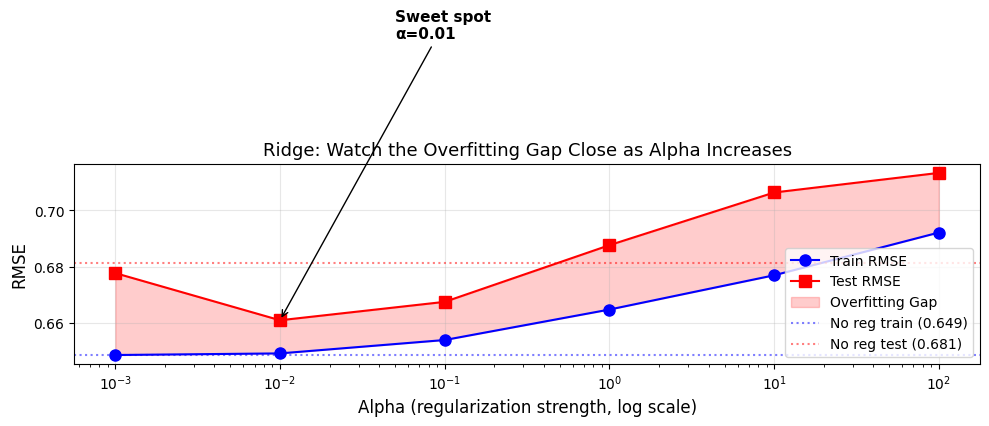

In [24]:
# TODO: Create a visualization showing how the gap closes for Ridge

plt.figure(figsize=(10, 6))
plt.semilogx(alphas, ridge_train_rmses, 'bo-', label='Train RMSE', markersize=8)
plt.semilogx(alphas, ridge_test_rmses, 'rs-', label='Test RMSE', markersize=8)

# Shade the gap between train and test (this IS the overfitting)
plt.fill_between(alphas, ridge_train_rmses, ridge_test_rmses, alpha=0.2, color='red', label='Overfitting Gap')

# Mark the no-regularization point
plt.axhline(y=rmse_train_poly, color='blue', linestyle=':', alpha=0.5, label=f'No reg train ({rmse_train_poly:.3f})')
plt.axhline(y=rmse_test_poly, color='red', linestyle=':', alpha=0.5, label=f'No reg test ({rmse_test_poly:.3f})')

plt.xlabel('Alpha (regularization strength, log scale)', fontsize=12)
plt.ylabel('RMSE', fontsize=12)
plt.title('Ridge: Watch the Overfitting Gap Close as Alpha Increases', fontsize=13)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

# Annotate the sweet spot
best_idx = np.argmin(ridge_test_rmses)
plt.annotate(f'Sweet spot\nα={alphas[best_idx]}',
             xy=(alphas[best_idx], ridge_test_rmses[best_idx]),
             xytext=(alphas[best_idx]*5, ridge_test_rmses[best_idx]+0.1),
             arrowprops=dict(arrowstyle='->', color='black'),
             fontsize=11, fontweight='bold')
plt.tight_layout()
# plt.show()


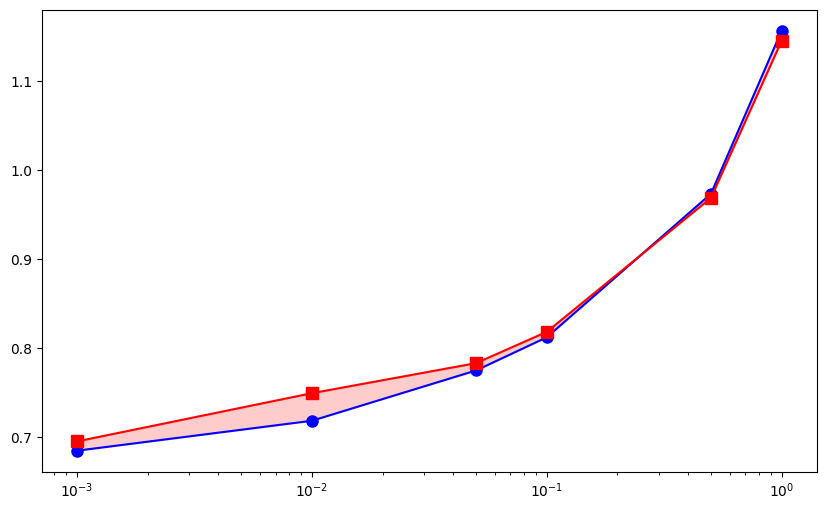

In [26]:
# TODO: Same gap visualization for Lasso

plt.figure(figsize=(10, 6))
plt.semilogx(alphas_lasso, lasso_train_rmses, 'bo-', label='Train RMSE', markersize=8)
plt.semilogx(alphas_lasso, lasso_test_rmses, 'rs-', label='Test RMSE', markersize=8)
plt.fill_between(alphas_lasso, lasso_train_rmses, lasso_test_rmses, alpha=0.2, color='red', label='Overfitting Gap')
#... (same pattern as above)


---
## Part 7: ElasticNet — The Best of Both Worlds

### Formula Reminder

$$\text{Loss}_{\text{EN}} = \sum_{i=1}^n (y_i - \hat{y}_i)^2 + \alpha \left[ \rho \sum_{j=1}^p |w_j| + \frac{(1-\rho)}{2} \sum_{j=1}^p w_j^2 \right]$$

### Why Use ElasticNet?

| Scenario | Problem with Lasso | Problem with Ridge | ElasticNet Solution |
|----------|-------------------|-------------------|--------------------|
| Correlated features | Randomly picks one, drops others | Keeps all, no selection | Groups them, selects as a group |
| p > n (more features than samples) | Can select at most n | No selection | No such limitation |
| Want selection + stability | Unstable selection | No selection at all | Stable selection |

### Pros and Cons

| Pros | Cons |
|------|------|
| Groups correlated features | Two hyperparameters to tune |
| Still does feature selection | More expensive to search |
| More stable than Lasso | Slightly less sparse than Lasso |
| Works when p > n | — |

### When to Use Each

- **Ridge**: All features relevant; multicollinearity present; want prediction accuracy
- **Lasso**: Many irrelevant features; want a sparse, interpretable model
- **ElasticNet**: Features are correlated AND you want sparsity; unsure which penalty fits best

---

**Your tasks:**
1. Train ElasticNet with combinations of `alpha` and `l1_ratio`
2. Find the best combination
3. Compare zero-coefficient count to Ridge and Lasso

**Functions to use:**
- `ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000)` — creates ElasticNet model
  - `l1_ratio=1.0` is pure Lasso; `l1_ratio=0.0` is pure Ridge
- Use a **nested loop**: outer over `alpha`, inner over `l1_ratio`
- `ElasticNetCV(l1_ratio=[...], alphas=[...], cv=5)` — auto-tunes both (stretch goal)

In [27]:
# TODO: Define parameter grids
alphas_en = [0.001, 0.01, 0.05, 0.1, 0.5, 1.0]
l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9]

# TODO: Nested loop — train ElasticNet for each (alpha, l1_ratio) combination
# Initialize best-tracking variables
best_en_rmse = 999
best_en_params = {}
en_results = []

for alpha in alphas_en:
    for l1 in l1_ratios:
        pass  # Replace with your code:
        en = ElasticNet(alpha=alpha, l1_ratio=l1, max_iter=10000)
        en.fit(X_train_scaled, y_train)
        rmse_te = np.sqrt(mean_squared_error(y_test, en.predict(X_test_scaled)))
        n_zeros = np.sum(en.coef_ == 0)
        en_results.append({'alpha': alpha, 'l1_ratio': l1, 'test_rmse': rmse_te, 'zeros': n_zeros})
        if rmse_te < best_en_rmse:
            best_en_rmse = rmse_te
            best_en_params = {'alpha': alpha, 'l1_ratio': l1}

# TODO: Print best parameters
print(f"Best ElasticNet: alpha={best_en_params['alpha']}, l1_ratio={best_en_params['l1_ratio']}")
print(f"  Test RMSE: {best_en_rmse:.4f}")

# TODO: Refit best model and save it
best_en = ElasticNet(alpha=best_en_params['alpha'], l1_ratio=best_en_params['l1_ratio'], max_iter=10000)
best_en.fit(X_train_scaled, y_train)

# Expected: Best is around alpha=0.001, l1_ratio=0.5-0.9
# Performance should be close to Lasso on this dataset.

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.903e+00, tolerance: 2.207e+00
  model = cd_fast.enet_coordinate_descent(


Best ElasticNet: alpha=0.001, l1_ratio=0.9
  Test RMSE: 0.6953


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.903e+00, tolerance: 2.207e+00
  model = cd_fast.enet_coordinate_descent(


ElasticNet(alpha=0.001, l1_ratio=0.9, max_iter=10000)

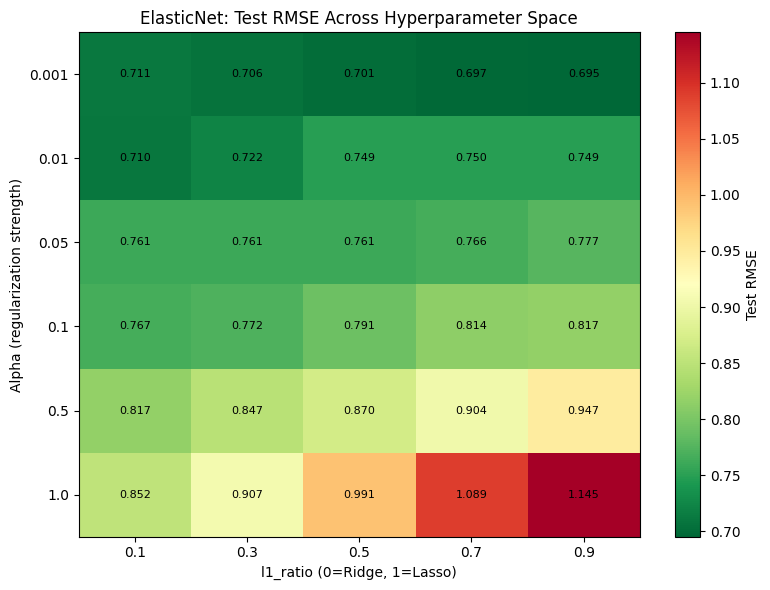

In [29]:
# TODO: Visualize ElasticNet results as a HEATMAP
# This shows how performance varies across the 2D hyperparameter space
# Rows = alpha, Columns = l1_ratio, Color = Test RMSE

# Hint: Convert en_results to a pivot table, then use plt.imshow()
#
en_df = pd.DataFrame(en_results)
heatmap_data = en_df.pivot(index='alpha', columns='l1_ratio', values='test_rmse')

plt.figure(figsize=(8, 6))
im = plt.imshow(heatmap_data.values, cmap='RdYlGn_r', aspect='auto')
plt.colorbar(im, label='Test RMSE')
plt.xticks(range(len(l1_ratios)), [f'{r:.1f}' for r in l1_ratios])
plt.yticks(range(len(alphas_en)), [f'{a}' for a in alphas_en])
plt.xlabel('l1_ratio (0=Ridge, 1=Lasso)')
plt.ylabel('Alpha (regularization strength)')
plt.title('ElasticNet: Test RMSE Across Hyperparameter Space')

# Annotate each cell with its RMSE value
for i in range(len(alphas_en)):
    for j in range(len(l1_ratios)):
        plt.text(j, i, f'{heatmap_data.values[i,j]:.3f}',
                 ha='center', va='center', fontsize=8)
plt.tight_layout()
plt.show()
#
# Look for the GREEN region (low RMSE) — that's the sweet spot!

**Questions:**

1. Does ElasticNet zero out more or fewer coefficients than Lasso at similar alpha? Why?

  ElasticNet typically zeros out fewer coefficients than Lasso at a similar overall alpha . This is because the L2 penalty component shrinks coefficients towards zero but rarely to exactly zero, counteracting Lasso's aggressive feature selection. It tends to group correlated features, meaning if one is selected, its correlated counterparts are also likely to be included with small, non-zero coefficients.

2. What happens as you move l1_rati` toward 1.0? Toward 0.0?

   As l1_ratio moves toward 1.0, ElasticNet behaves more like Lasso Regression, emphasizing the L1 penalty, leading to more coefficients being driven to zero for aggressive feature selection. Conversely, as l1_ratio moves toward 0.0, it behaves more like Ridge Regression, emphasizing the L2 penalty, shrinking all coefficients towards zero without setting them to exactly zero. When l1_ratio is exactly 1.0, it's Lasso; when 0.0, it's Ridge.

3. In what real-world scenario would ElasticNet clearly beat both Ridge and Lasso?

   ElasticNet clearly beats Ridge and Lasso when there are many highly correlated features, and sparsity (feature selection) is desired. Lasso might arbitrarily pick one feature from a correlated group, while Ridge keeps all, leading to complex models. ElasticNet selects groups of correlated features, offering a more stable and interpretable model by balancing feature selection and handling multicollinearity.

In [35]:
##Descion tree
# --- Decision Tree: tune max_depth ---
# TODO: Try max_depth = 3, 5, 7, 10, 15, None
# IMPORTANT: Use random_state=42 for reproducibility!
# Hint: None = unlimited depth (will memorize training data completely!)
# Expected: depth=None gives train RMSE ≈ 0 (perfect memorization) but high test RMSE
tree_results = {}
print(f"{'Depth':>7s}  {'Train RMSE':>12s}  {'Test RMSE':>12s}  {'Gap':>8s}")
print("-" * 45)
for depth in [3, 5, 7, 10, 15, None]:
    dt = DecisionTreeRegressor(max_depth=depth, random_state=42)
    dt.fit(X_train_raw_scaled, y_train)

    rmse_tr = np.sqrt(mean_squared_error(y_train, dt.predict(X_train_raw_scaled)))
    rmse_te = np.sqrt(mean_squared_error(y_test, dt.predict(X_test_raw_scaled)))

    tree_results[depth] = {'train': rmse_tr, 'test': rmse_te}
    print(f"{str(depth):>7s}  {rmse_tr:12.4f}  {rmse_te:12.4f}  {rmse_te-rmse_tr:8.4f}")

# Find the best depth for Decision Tree
best_tree_depth = min(tree_results, key=lambda d: tree_results[d]['test'])
best_tree_rmse_test = tree_results[best_tree_depth]['test']
best_tree_rmse_train = tree_results[best_tree_depth]['train']

  Depth    Train RMSE     Test RMSE       Gap
---------------------------------------------
      3        0.7860        0.8015    0.0155
      5        0.6959        0.7242    0.0283
      7        0.6154        0.6757    0.0603
     10        0.4700        0.6442    0.1743
     15        0.2293        0.6806    0.4513
   None        0.0000        0.7028    0.7028


---
## Part 8: Final Comparison Bar Chart

**Your tasks:**
1. Create a bar chart comparing Test RMSE of all 5 models
2. Also show the gap (Test - Train) for each model as a separate grouped bar

**Functions to use:**
- `plt.figure(figsize=(12, 5))` — create figure
- `plt.bar(x_positions, heights, width=0.35, color=..., label=...)` — bar chart
- For grouped bars: offset x positions by bar width
- `plt.xticks(positions, labels)` — set x-axis labels
- `plt.text(x, y, text, ha='center')` — annotate bars with values

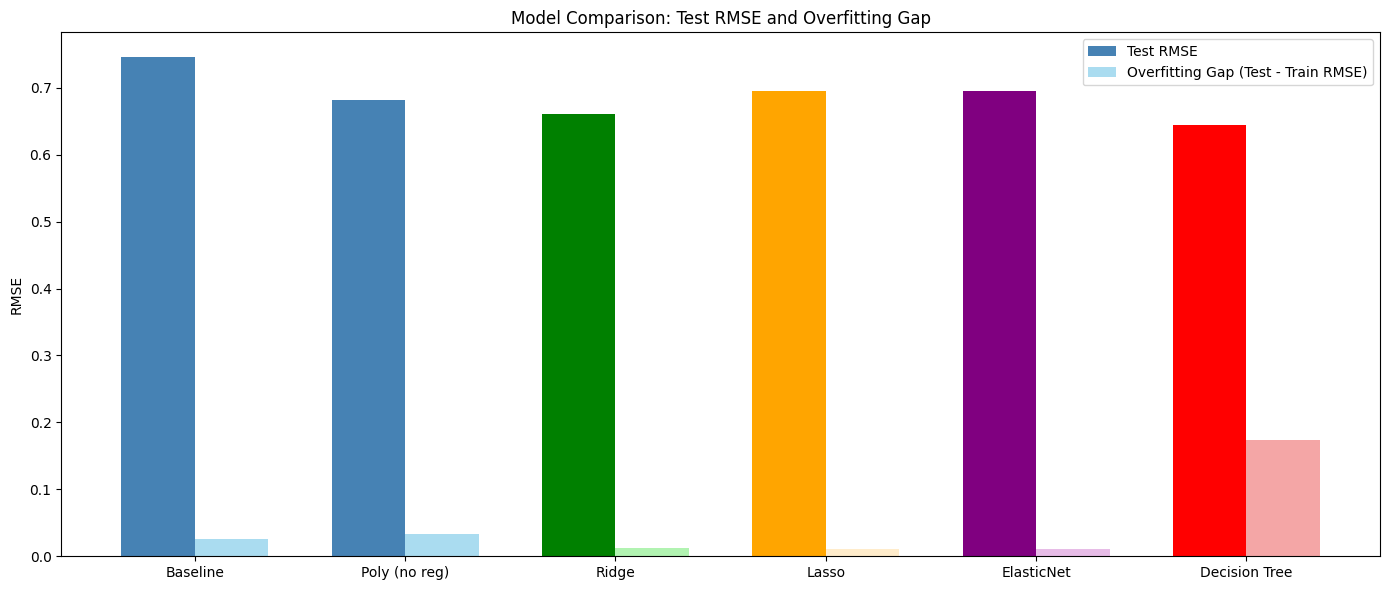

In [36]:
# TODO: Create a grouped bar chart showing Test RMSE AND the Gap for each model

# Ensure rmse_train_best_en is defined (from ElasticNet section)
# Ensure best_tree_rmse_test and best_tree_rmse_train are defined (from Decision Tree section)

model_names = ['Baseline', 'Poly (no reg)', 'Ridge', 'Lasso', 'ElasticNet', 'Decision Tree']
test_rmses = [
    rmse_test_baseline,
    rmse_test_poly,
    ridge_test_rmses[np.argmin(ridge_test_rmses)],
    lasso_test_rmses[np.argmin(lasso_test_rmses)],
    best_en_rmse,
    best_tree_rmse_test
]
train_rmses = [
    rmse_train_baseline,
    rmse_train_poly,
    ridge_train_rmses[np.argmin(ridge_test_rmses)],
    lasso_train_rmses[np.argmin(lasso_test_rmses)],
    rmse_train_best_en,
    best_tree_rmse_train
]
gaps = [test_rmse - train_rmse for test_rmse, train_rmse in zip(test_rmses, train_rmses)]

x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
bars1 = ax.bar(x - width/2, test_rmses, width, label='Test RMSE', color=['steelblue', 'steelblue', 'green', 'orange', 'purple', 'red'])
bars2 = ax.bar(x + width/2, gaps, width, label='Overfitting Gap (Test - Train RMSE)', color=['skyblue', 'skyblue', 'lightgreen', 'moccasin', 'plum', 'lightcoral'], alpha=0.7)

ax.set_ylabel('RMSE')
ax.set_title('Model Comparison: Test RMSE and Overfitting Gap')
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.legend()
plt.tight_layout()
plt.show()

---
## Part 9: Coefficient Analysis

Compare how each method affects the model coefficients.

**Your tasks:**
1. Create a 2x2 subplot showing |coefficient| histograms for each model
2. Print summary stats: max, mean, and zero count

**Functions to use:**
- `model.coef_` — the array of fitted coefficients
- `np.abs(coef)` — absolute values
- `fig, axes = plt.subplots(2, 2, figsize=(12, 8))` — 2x2 grid of plots
- `axes[i,j].hist(data, bins=20)` — histogram on a specific subplot
- `np.max()`, `np.mean()`, `np.sum(coef == 0)` — summary statistics

In [16]:
# TODO: Compare coefficient distributions across all 4 models

# fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# axes[0,0].hist(np.abs(linreg_poly.coef_), bins=20, color='indianred')
# axes[0,0].set_title('No Regularization')

# axes[0,1].hist(np.abs(best_ridge.coef_), bins=20, color='darkorange')
# axes[0,1].set_title('Ridge')

# axes[1,0].hist(np.abs(best_lasso.coef_), bins=20, color='green')
# axes[1,0].set_title('Lasso')

# axes[1,1].hist(np.abs(best_en.coef_), bins=20, color='purple')
# axes[1,1].set_title('ElasticNet')

# plt.tight_layout()
# plt.show()


---
## Part 10: Cross-Validation for Robust Model Selection

A single train/test split can be misleading. Use K-Fold cross-validation for a reliable comparison.

**Your tasks:**
1. Write a function that computes mean RMSE over 5-fold CV
2. Apply it to your best Ridge, Lasso, and ElasticNet models
3. Compare CV RMSE to test RMSE

**Functions to use:**
- `KFold(n_splits=5, shuffle=True, random_state=42)` — creates CV splitter
  - `.split(X)` — yields `(train_indices, val_indices)` pairs
- Inside each fold: `model.fit(X[train_idx], y[train_idx])` then `model.predict(X[val_idx])`
- Alternative: `from sklearn.model_selection import cross_val_score`
  - `cross_val_score(model, X, y, scoring='neg_mean_squared_error', cv=5)`
  - Returns negative MSE (negate and sqrt for RMSE)

In [17]:
# TODO: Write a cross-validation function

# def cv_rmse(model, X, y, n_folds=5):
#     kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)
#     rmses = []
#     for train_idx, val_idx in kf.split(X):
#         model.fit(X[train_idx], y[train_idx])
#         p = model.predict(X[val_idx])
#         rmses.append(np.sqrt(mean_squared_error(y[val_idx], p)))
#     return np.mean(rmses)

# TODO: Apply to each model
# print("5-Fold CV RMSE:")
# print(f"  Ridge: {cv_rmse(Ridge(alpha=...), X_train_scaled, y_train):.4f}")
# print(f"  Lasso: {cv_rmse(Lasso(alpha=..., max_iter=10000), X_train_scaled, y_train):.4f}")
# print(f"  ElasticNet: {cv_rmse(ElasticNet(alpha=..., l1_ratio=..., max_iter=10000), X_train_scaled, y_train):.4f}")


---
### Part 10b: Fine-Grained Alpha Search (Stretch Goal)

Zoom in with a finer grid to find the truly optimal alpha.

**Functions to use:**
- `np.logspace(start, stop, num)` — creates logarithmically spaced values
  - Example: `np.logspace(-3, 2, 50)` → 50 values from 0.001 to 100
- `from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV` — built-in CV classes
  - `RidgeCV(alphas=np.logspace(-3, 2, 50), cv=5)` — auto-finds best alpha
  - After fitting: `.alpha_` gives the optimal alpha found

In [18]:
# TODO: Fine-grained alpha search for Ridge using CV

# alphas_fine = np.logspace(-3, 2, 50)
# cv_scores = [cv_rmse(Ridge(alpha=a), X_train_scaled, y_train) for a in alphas_fine]

# plt.figure(figsize=(10, 5))
# plt.semilogx(alphas_fine, cv_scores, 'b-o', markersize=4)
# plt.xlabel('Alpha (log scale)')
# plt.ylabel('CV RMSE')
# plt.title('Ridge: CV RMSE vs Alpha')
# plt.grid(True, alpha=0.3)
# plt.show()

# best_alpha = alphas_fine[np.argmin(cv_scores)]
# print(f"Optimal alpha: {best_alpha:.4f}")


---
## Final Summary Table

Fill in this table with your results:

| Model | Alpha | l1_ratio | Test RMSE | CV RMSE | Overfitting Gap | # Zero Coefs |
|-------|-------|----------|-----------|---------|-----------------|---------------|
| Baseline (raw) | — | — | | — | | 0 |
| Polynomial (no reg) | — | — | | | | 0 |
| Ridge | | — | | | | 0 |
| Lasso | | — | | | | |
| ElasticNet | | | | | | |

---
## Part 11: Non-Linear Baselines — When Linear Models Aren't Enough

Even with regularization, linear models assume the target is a **linear function** of features (or polynomial combinations). Some patterns are **fundamentally non-linear** — no linear model can capture them.

In this section you'll train non-linear models on the **same data** and compare them to your regularized models.

---

### How Each Model Works

#### K-Nearest Neighbors (KNN)

**Idea:** To predict for a new house, find the K most similar houses in the training set and use a weighted average of their prices (with `weights='distance'`, closer neighbors count more):

$$\hat{y} = \frac{\sum_{i \in \mathcal{N}_K} \frac{1}{d_i} \cdot y_i}{\sum_{i \in \mathcal{N}_K} \frac{1}{d_i}}$$

where $d_i$ is the distance from the query point to neighbor $i$.

- **No model is learned** — it memorizes the training data and does lookup
- Small K = complex (follows every point) → overfits
- Large K = smooth (averages many points) → underfits
- **Needs scaling** — distances are meaningless if features have different scales

#### Decision Tree

**Idea:** Recursively split the data with IF-THEN rules. Each leaf predicts the average target of training samples that landed there.

- "If income > 5 AND latitude < 37 → predict $3.5"
- **No scaling needed** — splits are based on thresholds, not distances
- Small `max_depth` = simple model → underfits
- Large `max_depth` = memorizes training data → overfits

#### Random Forest

**Idea:** Train 100+ decision trees on random subsets of data, then average their predictions.

$$\hat{y} = \frac{1}{B} \sum_{b=1}^B \text{Tree}_b(x)$$

- Reduces the high variance of a single tree by averaging many decorrelated trees
- Hard to overfit — more trees only helps
- Very robust with default settings

#### Gradient Boosting

**Idea:** Sequentially add shallow trees, each one correcting the mistakes of the previous ensemble.

$$\hat{y}^{(t)} = \hat{y}^{(t-1)} + \eta \cdot \text{Tree}_t(x)$$

- Starts with a rough guess, then iteratively "zooms in" on errors
- Learning rate η controls how much each tree contributes
- Often the best-performing model on tabular data

#### Support Vector Regressor (SVR)

**Idea:** Fit a function that ignores small errors (within ε-tube) but penalizes large ones. Uses a "kernel trick" to handle non-linearity.

- RBF kernel maps data to a high-dimensional space where patterns become linear
- `C` controls regularization (small C = more regularized)
- Needs scaling — sensitive to feature magnitudes
- **⚠️ Slow:** O(n²) complexity — may take 15-30 seconds on this dataset

---

### When to Use Each

| Scenario | Best Choice |
|---|---|
| Few features, linear patterns | Ridge / Lasso / ElasticNet |
| Small data, non-linear | SVR (RBF kernel) |
| Need interpretability | Decision Tree (shallow) |
| Best accuracy, medium-large data | Gradient Boosting |
| Robust baseline, large data | Random Forest |
| Very local patterns | KNN (tuned K) |

---

### Your Tasks

1. Scale the **original 8 features** (NOT polynomial) — non-linear models capture non-linearity themselves
2. Train KNN, Decision Tree, Random Forest, Gradient Boosting, and SVR
3. Compute Train/Test RMSE for each
4. Create a comparison bar chart showing ALL models (linear + non-linear)
5. Discuss: which models win and why?

---

### Functions to Use

| Task | Function | Documentation |
|------|----------|---------------|
| KNN Regressor | `KNeighborsRegressor(n_neighbors=7, weights='distance')` | [sklearn.neighbors.KNeighborsRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsRegressor.html) |
| Decision Tree | `DecisionTreeRegressor(max_depth=10, random_state=42)` | [sklearn.tree.DecisionTreeRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html) |
| Random Forest | `RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)` | [sklearn.ensemble.RandomForestRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html) |
| Gradient Boosting | `GradientBoostingRegressor(n_estimators=200, max_depth=5, learning_rate=0.1)` | [sklearn.ensemble.GradientBoostingRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingRegressor.html) |
| SVR | `SVR(kernel='rbf', C=10.0, epsilon=0.1)` | [sklearn.svm.SVR](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVR.html) |
| Scale features | `StandardScaler()` → `.fit_transform(X_train)` / `.transform(X_test)` | [sklearn.preprocessing.StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html) |
| Compute RMSE | `np.sqrt(mean_squared_error(y_true, y_pred))` | [sklearn.metrics.mean_squared_error](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_squared_error.html) |
| Bar chart | `plt.bar(names, values, color=...)` | [matplotlib.pyplot.bar](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.bar.html) |

In [19]:
# New imports for non-linear models
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

In [20]:
# ============================================================
# STEP 0: Scale the ORIGINAL 8 features for non-linear models
# WHY original features? Non-linear models capture non-linearity NATIVELY —
# they don't need polynomial expansion. Giving them raw features is a FAIR
# comparison because they can find interactions on their own.
#
# NOTE: We scale for ALL models here even though Decision Trees don't need it.
# Reason: KNN and SVR DO need scaling, and scaling doesn't hurt trees (just
# transforms thresholds). Using one scaled dataset keeps the code simple.
# ============================================================

scaler_raw = StandardScaler()
X_train_raw_scaled = scaler_raw.fit_transform(X_train)
X_test_raw_scaled = scaler_raw.transform(X_test)

print(f"Non-linear models will use: {X_train_raw_scaled.shape[1]} original features")
print(f"Linear models used: {X_train_scaled.shape[1]} polynomial features")
print(f"\nThis is a FAIR comparison — non-linear models capture interactions natively.")

Non-linear models will use: 8 original features
Linear models used: 44 polynomial features

This is a FAIR comparison — non-linear models capture interactions natively.


In [21]:
# ============================================================
# WORKED EXAMPLE: Training KNN Regressor with hyperparameter tuning
# Same pattern as Ridge/Lasso — loop over hyperparameter values, track RMSE
# ============================================================

# Step 1: Define hyperparameter values to try
k_values = [3, 5, 7, 10, 15, 20]

# Step 2: Loop and collect results (same pattern as alphas loop!)
knn_results = {}
print(f"{'K':>5s}  {'Train RMSE':>12s}  {'Test RMSE':>12s}  {'Gap':>8s}")
print("-" * 45)

for k in k_values:
    # Create model with this K value
    knn = KNeighborsRegressor(n_neighbors=k, weights='distance')

    # Fit on training data
    knn.fit(X_train_raw_scaled, y_train)

    # Compute RMSE for both sets
    rmse_tr = np.sqrt(mean_squared_error(y_train, knn.predict(X_train_raw_scaled)))
    rmse_te = np.sqrt(mean_squared_error(y_test, knn.predict(X_test_raw_scaled)))

    # Store results
    knn_results[k] = {'train': rmse_tr, 'test': rmse_te}
    print(f"{k:5d}  {rmse_tr:12.4f}  {rmse_te:12.4f}  {rmse_te-rmse_tr:8.4f}")

# Step 3: Find the best K
best_k = min(knn_results, key=lambda k: knn_results[k]['test'])
print(f"\nBest K = {best_k} (Test RMSE = {knn_results[best_k]['test']:.4f})")
print(f"\nNotice: small K has a HUGE gap (overfitting), large K has higher test error (underfitting)")
print(f"Same bias-variance tradeoff as alpha in Ridge/Lasso!")

    K    Train RMSE     Test RMSE       Gap
---------------------------------------------
    3        0.0000        0.6827    0.6827
    5        0.0000        0.6557    0.6557
    7        0.0000        0.6509    0.6509
   10        0.0000        0.6452    0.6452
   15        0.0000        0.6426    0.6426
   20        0.0000        0.6455    0.6455

Best K = 15 (Test RMSE = 0.6426)

Notice: small K has a HUGE gap (overfitting), large K has higher test error (underfitting)
Same bias-variance tradeoff as alpha in Ridge/Lasso!


In [22]:
# ============================================================
# YOUR TURN: Train the remaining 4 non-linear models
# Follow the same pattern as the KNN example above
# ============================================================

# --- Decision Tree: tune max_depth ---
# TODO: Try max_depth = 3, 5, 7, 10, 15, None
# IMPORTANT: Use random_state=42 for reproducibility!
# Hint: None = unlimited depth (will memorize training data completely!)
# Expected: depth=None gives train RMSE ≈ 0 (perfect memorization) but high test RMSE
tree_results = {}
for depth in [3, 5, 7, 10, 15, None]:
    # dt = DecisionTreeRegressor(max_depth=depth, random_state=42)
    pass  # Replace with your code

# --- Random Forest ---
# TODO: Train with n_estimators=100, random_state=42, n_jobs=-1
# n_jobs=-1 uses all CPU cores (speeds up training ~2-3x)
# This is an ensemble of 100 trees — expect MUCH better than single tree
# Expected: Test RMSE ~ 0.50-0.55
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
# ... fit and compute RMSE ...

# --- Gradient Boosting ---
# TODO: Train with n_estimators=200, max_depth=5, learning_rate=0.1, random_state=42
# Expected: Test RMSE ~ 0.45-0.52 (likely the BEST model)
# Note: this will take a few seconds longer than other models
gb = GradientBoostingRegressor(n_estimators=200, max_depth=5, learning_rate=0.1, random_state=42)
# ... fit and compute RMSE ...

# --- SVR (Support Vector Regressor) ---
# TODO: Train with kernel='rbf', C=10.0, epsilon=0.1
# Note: SVR is O(n²) — may take 10-30 seconds on this dataset
# Expected: Test RMSE ~ 0.55-0.65
svr = SVR(kernel='rbf', C=10.0, epsilon=0.1)
# ... fit and compute RMSE ...

# TODO: Print a summary table of ALL non-linear models
# Expected format:
#   Model              Train RMSE    Test RMSE    Gap
#   KNN (K=7)            0.xxxx       0.xxxx    0.xxxx
#   Tree (depth=10)      0.xxxx       0.xxxx    0.xxxx
#   Random Forest        0.xxxx       0.xxxx    0.xxxx
#   Gradient Boosting    0.xxxx       0.xxxx    0.xxxx
#   SVR                  0.xxxx       0.xxxx    0.xxxx

---
## Reflection Questions

1. **When would you choose Ridge over Lasso?**  
   *Your answer:*

2. **When would you choose Lasso over Ridge?**  
   *Your answer:*

3. **When would ElasticNet be the best choice? Give a concrete example.**  
   *Your answer:*

4. **What happens if alpha is too large? Too small?**  
   *Your answer:*

5. **Why is feature scaling important for regularization?**  
   *Your answer:*

6. **Looking at your gap visualization: what does the shaded area represent in terms of model behavior?**  
   *Your answer:*

7. **If you had 1000 features but suspected only 20 matter, and many of the 1000 are correlated, which method would you try first and why?**  
   *Your answer:*

8. **Why do non-linear models use the original 8 features instead of polynomial features? Is the comparison fair?**  
   *Your answer:*

9. **Gradient Boosting likely has the best RMSE. Should you always use it? What are the tradeoffs?**  
   *Your answer:*

In [23]:
# TODO: Create a GRAND COMPARISON bar chart — ALL models side by side
# This is the payoff visualization: linear models vs non-linear models

# Hint: Collect all your results into lists:
# all_names = ['OLS', 'Ridge', 'Lasso', 'ElasticNet', 'KNN', 'Tree', 'Random Forest', 'Grad. Boost', 'SVR']
# all_test_rmses = [rmse_test_baseline, best_ridge_rmse, best_lasso_rmse, best_en_rmse,
#                   best_knn_rmse, best_tree_rmse, rf_rmse, gb_rmse, svr_rmse]

# fig, ax = plt.subplots(figsize=(14, 6))
# colors = ['steelblue']*4 + ['crimson']*5  # blue for linear, red for non-linear
# bars = ax.bar(all_names, all_test_rmses, color=colors, alpha=0.8, edgecolor='black')

# # Add value labels on top of each bar
# for bar, val in zip(bars, all_test_rmses):
#     ax.text(bar.get_x() + bar.get_width()/2, val + 0.01, f'{val:.3f}',
#             ha='center', fontsize=9, fontweight='bold')

# # Add a vertical line separating linear from non-linear
# ax.axvline(x=3.5, color='gray', linestyle=':', alpha=0.5)
# ax.text(1.5, max(all_test_rmses)*0.95, 'LINEAR', ha='center', fontsize=11, color='steelblue')
# ax.text(6.5, max(all_test_rmses)*0.95, 'NON-LINEAR', ha='center', fontsize=11, color='crimson')

# ax.set_ylabel('Test RMSE (lower = better)', fontsize=12)
# ax.set_title('Grand Comparison: Can Non-Linear Models Beat Regularized Linear Models?', fontsize=13)
# plt.xticks(rotation=15)
# plt.tight_layout()
# plt.show()

# TODO: Print which model wins and by how much
# print(f"Best linear model: ... (RMSE = ...)")
# print(f"Best non-linear model: ... (RMSE = ...)")
# print(f"Improvement: ...%")

---
## Quick Reference: Key sklearn APIs

| Class | Module | Key Parameters | Notes |
|-------|--------|----------------|-------|
| `LinearRegression` | `sklearn.linear_model` | `fit_intercept` | No regularization (OLS) |
| `Ridge` | `sklearn.linear_model` | `alpha` | L2 penalty only |
| `Lasso` | `sklearn.linear_model` | `alpha`, `max_iter` | L1 penalty, sparse |
| `ElasticNet` | `sklearn.linear_model` | `alpha`, `l1_ratio`, `max_iter` | Combined L1+L2 |
| `RidgeCV` | `sklearn.linear_model` | `alphas` | Auto-tunes alpha |
| `LassoCV` | `sklearn.linear_model` | `alphas`, `cv` | Auto-tunes alpha |
| `ElasticNetCV` | `sklearn.linear_model` | `alphas`, `l1_ratio`, `cv` | Auto-tunes both |
| `PolynomialFeatures` | `sklearn.preprocessing` | `degree`, `include_bias` | Feature expansion |
| `StandardScaler` | `sklearn.preprocessing` | — | Z-score normalization |
| `KFold` | `sklearn.model_selection` | `n_splits`, `shuffle` | CV splits |
| `mean_squared_error` | `sklearn.metrics` | `y_true`, `y_pred` | MSE metric |
| `r2_score` | `sklearn.metrics` | `y_true`, `y_pred` | R² metric |

**Documentation:** https://scikit-learn.org/stable/modules/linear_model.html